# simple Neural network using Numpy

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Numpy Model : forward prop 
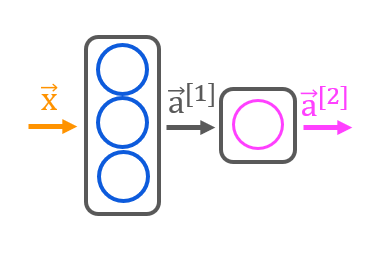

## about the network shown above
- `X` Input matrix 
- first `hidden layer` -> 3-Neurons each calculates aj = g(w.x)+b
- second `output layer` -> 1-Neuron calculate aj = g(w.x)+b
- the activation function : `sigmoid` (prediction task)
---

`X`   : shape (m, n)           # m samples, n input features

`W1`   : shape (n, j)           # weights from input → j neurons in first hidden layer  
`b1`   : shape (j,)             # one bias per hidden neuron

`a1`   = sigmoid(X @ W1 + b1)   # shape (m, j)

`W2`   : shape (j, n_output)    # weights from hidden → output neurons  
`b2`   : shape (n_output,)      # one bias per output neuron

`a2`   = sigmoid(a1 @ W2 + b2)  # shape (m, n_output)


In [8]:
# Functions 

# 1-Activation function (sigmoid)
def sigmoid(z):
    z= np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

    
# 2-Dense
def dense(a_in,W,b,):
    z = np.dot(a_in,W) + b
    a_out = sigmoid(z)
    return a_out 

# same as above
def dense_vectorized(a_in,W,B):
    z = a_in @ W + B
    a_out = sigmoid(z)
    return a_out


# 3-Sequential
def sequential(X,W1,b1,W2,b2):
    a1 = dense(X,W1,b1) # shape (m,n_hidden)
    a2 = dense(a1,W2,b2)
    return a2


---
# simple example 

In [9]:
X_tst = np.array([
    [200,13.9],  # postive example
    [200,17]])# negative example
#-------------------------------------- For layer 1 , 3-neurons
W1_tmp = np.array( [[-8.93,  0.29, 12.9 ],[-0.1,  -7.32, 10.81]])
b1_tmp = np.array( [-9.82, -9.28,  0.96] )

#------------------------------------- For layer 2 , 1-neuron
W2_tmp = np.array( [[-31.18], [-27.59], [-32.56]] )
b2_tmp = np.array( [15.41] )

In [10]:
print(f"X shape : {X_tst.shape}") 
print(f"w1 shape : {W1_tmp.shape}")
print(f"b1 shape : {b1_tmp.shape}")
#------------------------------------- For layer 2 , 1-neuron
print(f"W2 shape : {W2_tmp.shape}")
print(f"wb2 shape : {b2_tmp.shape}")

X shape : (2, 2)
w1 shape : (2, 3)
b1 shape : (3,)
W2 shape : (3, 1)
wb2 shape : (1,)


# Normalize data

In [11]:
#Normalization
norm_l = tf.keras.layers.Normalization(axis= -1)
norm_l.adapt(X_tst)
X_tstn = norm_l(X_tst) 
# run 
predictions = sequential(X_tstn, W1_tmp, b1_tmp, W2_tmp, b2_tmp)

In [12]:
predictions

array([[9.99993856e-01],
       [3.55870744e-08]])

In [13]:
yhat = (predictions >= 0.5).astype(int)

print(f"decisions = \n{yhat}")


decisions = 
[[1]
 [0]]


---
# Prediction using `coffee roasting data set`

# Dataset

In [14]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

In [15]:
X,y = load_coffee_data() # X[0] = Temp , X[1]: Time

In [16]:
X.shape,y.shape

((200, 2), (200, 1))

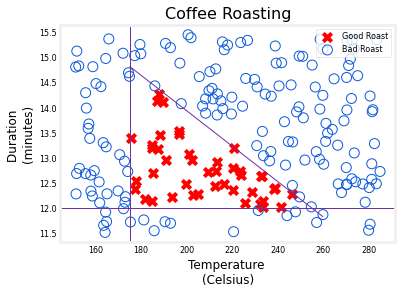

# Normalize Data

In [17]:
print(f"Temp Max,Min pre normailzation : {np.max(X[:,0]):0.2f} , {np.min(X[:,0]):0.2f}")
print(f"Duration Max,Min pre normailzation : {np.max(X[:,1]):0.2f} , {np.min(X[:,1]):0.2f}")

Temp Max,Min pre normailzation : 284.99 , 151.32
Duration Max,Min pre normailzation : 15.45 , 11.51


In [18]:
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X) # calculates the mean and variance
Xn = norm_l(X)

In [19]:
print(f"Temp Max,Min after normailzation : {np.max(Xn[:,0]):0.2f} , {np.min(Xn[:,0]):0.2f}")
print(f"Duration Max,Min after normailzation : {np.max(Xn[:,1]):0.2f} , {np.min(Xn[:,1]):0.2f}")

Temp Max,Min after normailzation : 1.66 , -1.69
Duration Max,Min after normailzation : 1.79 , -1.70


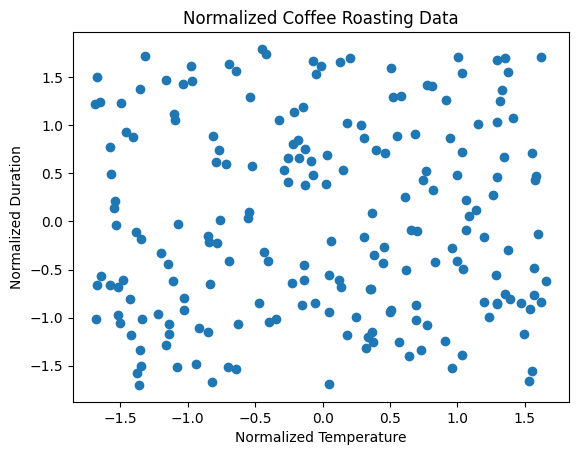

In [20]:
Xn_np = Xn.numpy()  # Convert from Tensor to NumPy array
plt.scatter(Xn_np[:, 0], Xn_np[:, 1])
plt.title("Normalized Coffee Roasting Data")
plt.xlabel("Normalized Temperature")
plt.ylabel("Normalized Duration")
plt.show()


In [21]:
Xn.shape

TensorShape([200, 2])

In [22]:
W1 = np.array([[1,2,3],
              [2,3,5]])
print(f'W2 shape : {W1.shape}')
b1 = np.array([-1,1,2])
print(f'b1 shape : {b1.shape}')

W2 shape : (2, 3)
b1 shape : (3,)


In [23]:
W2 = np.array([[1],
              [2],
              [-1]])
print(f'W2 shape : {W2.shape}')
b2 = np.array([1])
print(f'b2 shape : {b2.shape}')

W2 shape : (3, 1)
b2 shape : (1,)


In [24]:
ypred = sequential(Xn,W1_tmp,b1_tmp,W2_tmp,b2_tmp)

In [25]:
ypred[:10]

array([[9.99995609e-01],
       [7.42292445e-08],
       [3.56297639e-08],
       [1.26076199e-10],
       [9.99987214e-01],
       [9.96358411e-01],
       [4.57740730e-08],
       [1.66895930e-07],
       [3.56319798e-08],
       [9.99986164e-01]])

In [26]:
y_hat = (ypred >= 0.5).astype(int)

In [27]:
y_hat[:10]

array([[1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1]])

In [28]:
y_hat=y_hat.flatten() # 1d for ploting

good_roast = y_hat == 1
bad_roast = y_hat == 0 

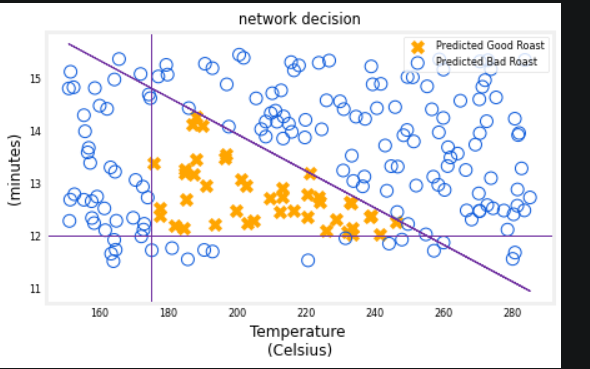

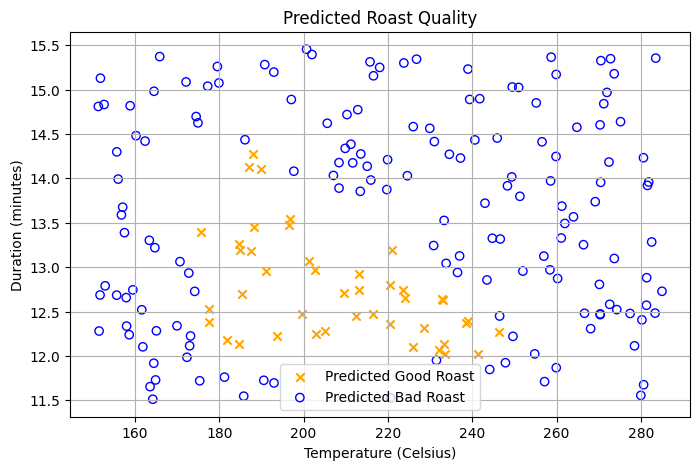

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(X[good_roast, 0], X[good_roast, 1], c='orange', marker='x', label='Predicted Good Roast')
plt.scatter(X[bad_roast, 0], X[bad_roast, 1], facecolors='none', edgecolors='blue', label='Predicted Bad Roast')

plt.xlabel("Temperature (Celsius)")
plt.ylabel("Duration (minutes)")
plt.title("Predicted Roast Quality")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
X_good = X[good_roast]

In [31]:
X_good[:5]

array([[185.31763812,  12.69396457],
       [187.12086467,  14.12973206],
       [225.90586448,  12.10024905],
       [202.86935247,  12.24901028],
       [196.70468985,  13.54426389]])

In [32]:
X_bad = X[bad_roast]

In [33]:
X_bad[:5]

array([[259.92047498,  11.86766377],
       [231.01357101,  14.41424211],
       [175.3666449 ,  11.72058651],
       [208.40515676,  14.17718919],
       [207.07593089,  14.0327376 ]])